In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import (EarlyStopping,
                                        ModelCheckpoint,
                                        ReduceLROnPlateau)
from tensorflow.keras.models import load_model

from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_curve, auc)
from sklearn.model_selection import train_test_split

import os, json, zipfile
from datetime import datetime
from collections import Counter

In [2]:
NUM_WORDS  = 10000   # Top 10k vocabulary
MAXLEN     = 200     # Max review length (words)

(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = \
    keras.datasets.imdb.load_data(num_words=NUM_WORDS)

# Word Index (for decoding)
word_index     = keras.datasets.imdb.get_word_index()
index_to_word  = {v+3: k for k, v in word_index.items()}
index_to_word[0] = '<PAD>'
index_to_word[1] = '<START>'
index_to_word[2] = '<UNK>'
index_to_word[3] = '<UNUSED>'

print(f"✅ Dataset Loaded!")
print(f"   Train Samples    : {len(X_train_raw):,}")
print(f"   Test  Samples    : {len(X_test_raw):,}")
print(f"   Vocabulary Size  : {NUM_WORDS:,}")
print(f"   Max Sequence Len : {MAXLEN}")
print(f"   Classes          : 2  (Positive / Negative)")
print(f"\n   Label Distribution:")
print(f"   Train → Positive: {y_train_raw.sum():,} | Negative: {(1-y_train_raw).sum():,}")
print(f"   Test  → Positive: {y_test_raw.sum():,}  | Negative: {(1-y_test_raw).sum():,}")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Dataset Loaded!
   Train Samples    : 25,000
   Test  Samples    : 25,000
   Vocabulary Size  : 10,000
   Max Sequence Len : 200
   Classes          : 2  (Positive / Negative)

   Label Distribution:
   Train → Positive: 12,500 | Negative: 12,500
   Test  → Positive: 12,500  | Negative: 12,500


In [3]:
def decode_review(encoded):
    return ' '.join([index_to_word.get(i, '?') for i in encoded])

for i in range(3):
    label = "⭐ POSITIVE" if y_train_raw[i] == 1 else "👎 NEGATIVE"
    text  = decode_review(X_train_raw[i])
    print(f"\n[Review {i+1}] Label: {label}")
    print(f"   Length : {len(X_train_raw[i])} words")
    print(f"   Text   : {text[:200]}...")


[Review 1] Label: ⭐ POSITIVE
   Length : 218 words
   Text   : <START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and ...

[Review 2] Label: 👎 NEGATIVE
   Length : 189 words
   Text   : <START> big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horror movies and i've seen hundreds but this had got to be on of the...

[Review 3] Label: 👎 NEGATIVE
   Length : 141 words
   Text   : <START> this has to be one of the worst films of the 1990s when my friends i were watching this film being the target audience it was aimed at we just sat watched the first half an hour with our jaws ...


In [4]:
# --- 4.1 Empty / Null Reviews ---
print("\n📌 Step 1: Empty/Null Review Check...")
train_empty = sum(1 for x in X_train_raw if len(x) == 0)
test_empty  = sum(1 for x in X_test_raw  if len(x) == 0)
print(f"   Train Empty Reviews : {train_empty}")
print(f"   Test  Empty Reviews : {test_empty}")


📌 Step 1: Empty/Null Review Check...
   Train Empty Reviews : 0
   Test  Empty Reviews : 0


In [5]:
# --- 4.2 Label Validation ---
print("\n📌 Step 2: Label Validation...")
unique_labels = np.unique(np.concatenate([y_train_raw, y_test_raw]))
print(f"   Unique Labels   : {unique_labels}  (0=Negative, 1=Positive)")
print(f"   Invalid Labels  : {sum(1 for y in y_train_raw if y not in [0,1])}")


📌 Step 2: Label Validation...
   Unique Labels   : [0 1]  (0=Negative, 1=Positive)
   Invalid Labels  : 0


In [6]:
# --- 4.3 Review Length Stats ---
print("\n📌 Step 3: Review Length Statistics...")
train_lengths = [len(x) for x in X_train_raw]
test_lengths  = [len(x) for x in X_test_raw]

print(f"   Train — Min:{min(train_lengths)} | "
      f"Max:{max(train_lengths)} | "
      f"Mean:{np.mean(train_lengths):.0f} | "
      f"Median:{np.median(train_lengths):.0f}")
print(f"   Test  — Min:{min(test_lengths)} | "
      f"Max:{max(test_lengths)} | "
      f"Mean:{np.mean(test_lengths):.0f} | "
      f"Median:{np.median(test_lengths):.0f}")


📌 Step 3: Review Length Statistics...
   Train — Min:11 | Max:2494 | Mean:239 | Median:178
   Test  — Min:7 | Max:2315 | Mean:231 | Median:174


In [7]:
# --- 4.4 Out-of-Vocabulary Tokens ---
print("\n📌 Step 4: OOV Token Check...")
oov_count = sum(
    sum(1 for token in review if token == 2)  # 2 = <UNK>
    for review in X_train_raw[:1000]
)
print(f"   OOV (<UNK>) tokens in first 1000 reviews : {oov_count}")


📌 Step 4: OOV Token Check...
   OOV (<UNK>) tokens in first 1000 reviews : 14168


In [8]:
# --- 4.5 Duplicate Reviews ---
print("\n📌 Step 5: Duplicate Check (sample 5000)...")
sample_str   = [str(x[:50]) for x in X_train_raw[:5000]]
unique_count = len(set(sample_str))
print(f"   Duplicates Found : {5000 - unique_count}")


📌 Step 5: Duplicate Check (sample 5000)...
   Duplicates Found : 3


In [9]:
# --- 5.1 Pad Sequences ---
print("\n📌 Step 1: Padding/Truncating Sequences...")
X_train_pad = pad_sequences(X_train_raw, maxlen=MAXLEN,
                             padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_raw,  maxlen=MAXLEN,
                             padding='post', truncating='post')
print(f"   Before Padding : variable length (e.g. {len(X_train_raw[0])})")
print(f"   After  Padding : {X_train_pad.shape}  (all same length)")

# --- 5.2 Labels as numpy arrays ---
print("\n📌 Step 2: Label Preparation...")
y_train = y_train_raw.astype('float32')
y_test  = y_test_raw.astype('float32')
print(f"   Train Labels Shape : {y_train.shape}")
print(f"   Test  Labels Shape : {y_test.shape}")

# --- 5.3 Train / Validation Split ---
print("\n📌 Step 3: Train/Validation Split (85/15)...")
X_train_f, X_val, y_train_f, y_val = train_test_split(
    X_train_pad, y_train,
    test_size=0.15, random_state=42,
    stratify=y_train
)
print(f"   Train Set : {X_train_f.shape[0]:,} samples")
print(f"   Val   Set : {X_val.shape[0]:,} samples")
print(f"   Test  Set : {X_test_pad.shape[0]:,} samples")

# --- 5.4 Summary ---
print(f"\n{'='*50}")
print("📊 PREPROCESSING SUMMARY")
print(f"{'='*50}")
print(f"   Vocabulary Size : {NUM_WORDS:,}")
print(f"   Sequence Length : {MAXLEN}")
print(f"   Padding         : Post-padding with 0")
print(f"   Truncating      : Post-truncating")
print(f"   Train Samples   : {X_train_f.shape[0]:,}")
print(f"   Val   Samples   : {X_val.shape[0]:,}")
print(f"   Test  Samples   : {X_test_pad.shape[0]:,}")


📌 Step 1: Padding/Truncating Sequences...
   Before Padding : variable length (e.g. 218)
   After  Padding : (25000, 200)  (all same length)

📌 Step 2: Label Preparation...
   Train Labels Shape : (25000,)
   Test  Labels Shape : (25000,)

📌 Step 3: Train/Validation Split (85/15)...
   Train Set : 21,250 samples
   Val   Set : 3,750 samples
   Test  Set : 25,000 samples

📊 PREPROCESSING SUMMARY
   Vocabulary Size : 10,000
   Sequence Length : 200
   Padding         : Post-padding with 0
   Truncating      : Post-truncating
   Train Samples   : 21,250
   Val   Samples   : 3,750
   Test  Samples   : 25,000


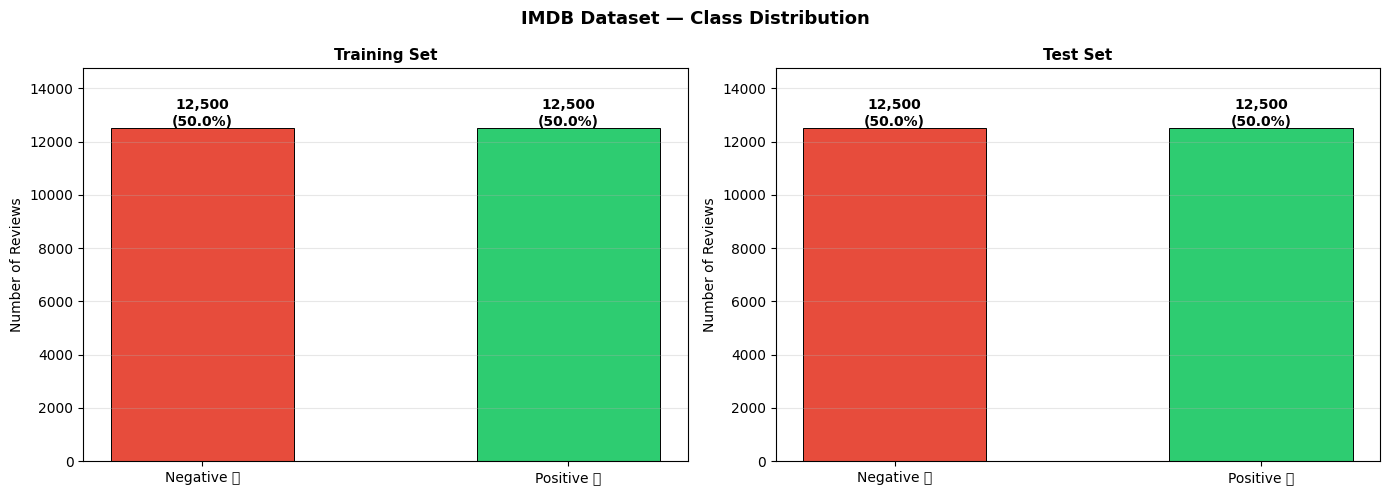

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('IMDB Dataset — Class Distribution',
             fontsize=13, fontweight='bold')

labels     = ['Negative 👎', 'Positive ⭐']
colors     = ['#e74c3c', '#2ecc71']

for ax, (data, title) in zip(axes, [
    (y_train_raw, 'Training Set'),
    (y_test_raw,  'Test Set')
]):
    counts = [np.sum(data == 0), np.sum(data == 1)]

    # Bar chart
    bars = ax.bar(labels, counts, color=colors,
                  edgecolor='black', lw=0.7, width=0.5)
    ax.set_title(f'{title}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Number of Reviews', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(counts) * 1.18)

    for bar, c in zip(bars, counts):
        pct = c / sum(counts) * 100
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 100,
                f'{c:,}\n({pct:.1f}%)',
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

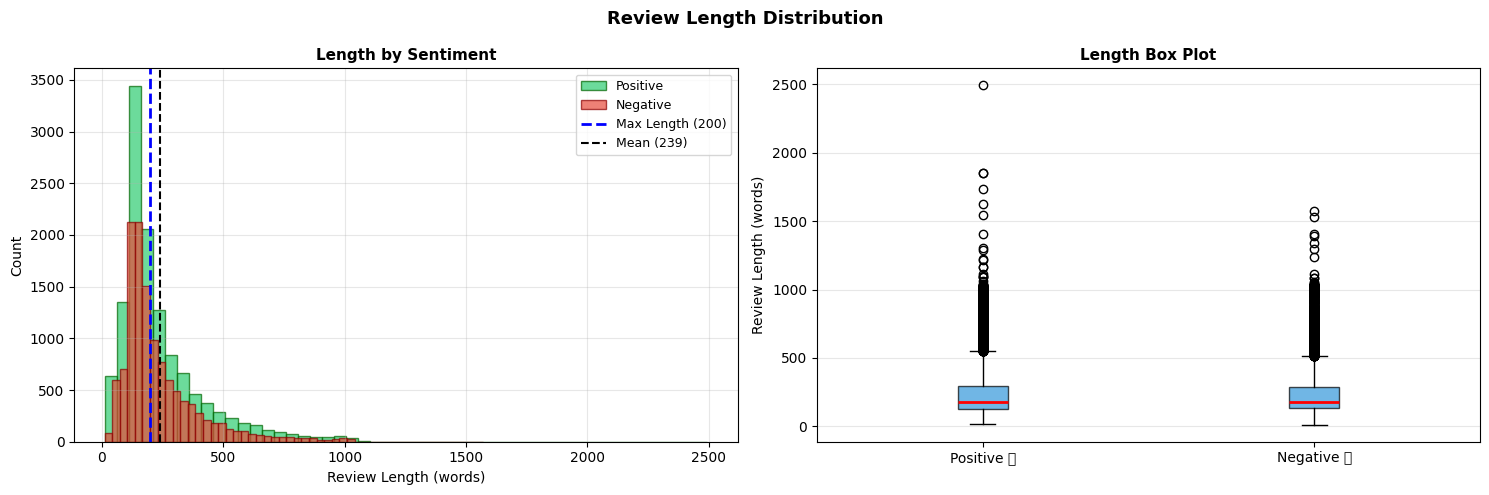

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Review Length Distribution', fontsize=13, fontweight='bold')

train_pos_len = [len(X_train_raw[i])
                 for i in range(len(X_train_raw)) if y_train_raw[i] == 1]
train_neg_len = [len(X_train_raw[i])
                 for i in range(len(X_train_raw)) if y_train_raw[i] == 0]

# Histogram
axes[0].hist(train_pos_len, bins=50, alpha=0.7,
             color='#2ecc71', label='Positive', edgecolor='darkgreen')
axes[0].hist(train_neg_len, bins=50, alpha=0.7,
             color='#e74c3c', label='Negative', edgecolor='darkred')
axes[0].axvline(MAXLEN, color='blue', ls='--', lw=2,
                label=f'Max Length ({MAXLEN})')
axes[0].axvline(np.mean(train_lengths), color='black',
                ls='--', lw=1.5,
                label=f'Mean ({np.mean(train_lengths):.0f})')
axes[0].set_title('Length by Sentiment', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Review Length (words)')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Box Plot
axes[1].boxplot([train_pos_len, train_neg_len],
                labels=['Positive ⭐', 'Negative 👎'],
                patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Length Box Plot', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Review Length (words)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('02_review_length.png', dpi=120, bbox_inches='tight')
plt.show()

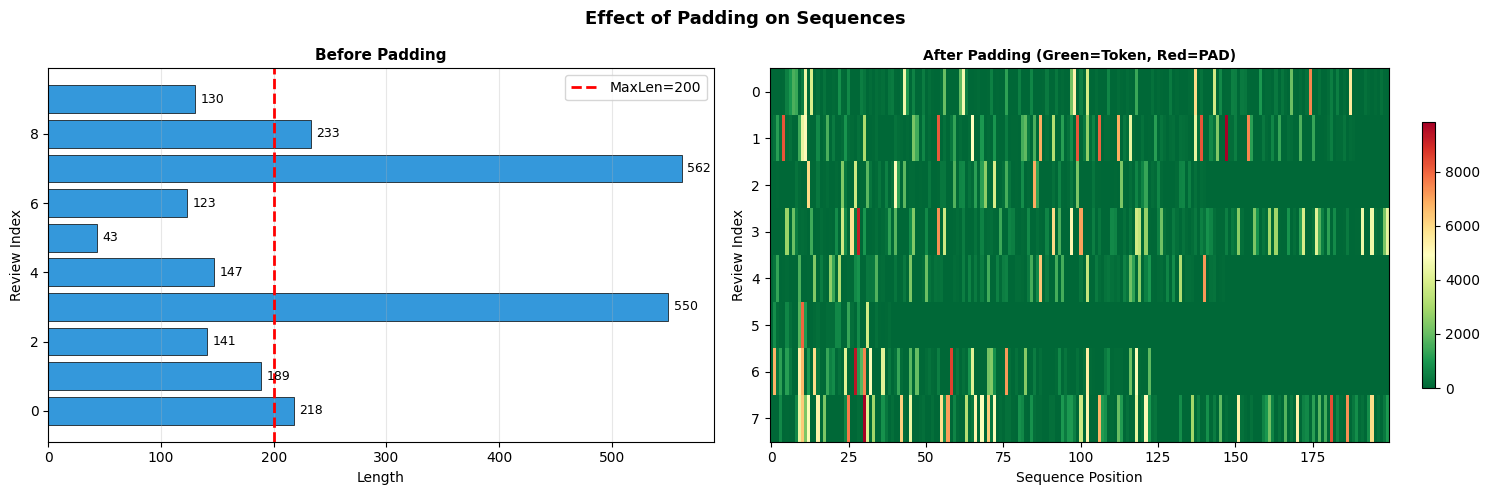

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Effect of Padding on Sequences',
             fontsize=13, fontweight='bold')

# Before padding (first 10 reviews)
before_lens = [len(X_train_raw[i]) for i in range(10)]
after_lens  = [MAXLEN] * 10

x_pos = range(10)
axes[0].barh(list(x_pos), before_lens,
             color='#3498db', edgecolor='black', lw=0.5)
axes[0].axvline(MAXLEN, color='red', ls='--',
                lw=2, label=f'MaxLen={MAXLEN}')
axes[0].set_title('Before Padding', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Length')
axes[0].set_ylabel('Review Index')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(before_lens):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

# After padding — heatmap of first 8 reviews
sample_padded = X_train_pad[:8]
mask = (sample_padded == 0).astype(int)

axes[1].imshow(sample_padded, aspect='auto', cmap='RdYlGn_r')
axes[1].set_title('After Padding (Green=Token, Red=PAD)',
                  fontsize=10, fontweight='bold')
axes[1].set_xlabel('Sequence Position')
axes[1].set_ylabel('Review Index')
plt.colorbar(axes[1].images[0], ax=axes[1], fraction=0.02)

plt.tight_layout()
plt.savefig('03_padding_effect.png', dpi=120, bbox_inches='tight')
plt.show()

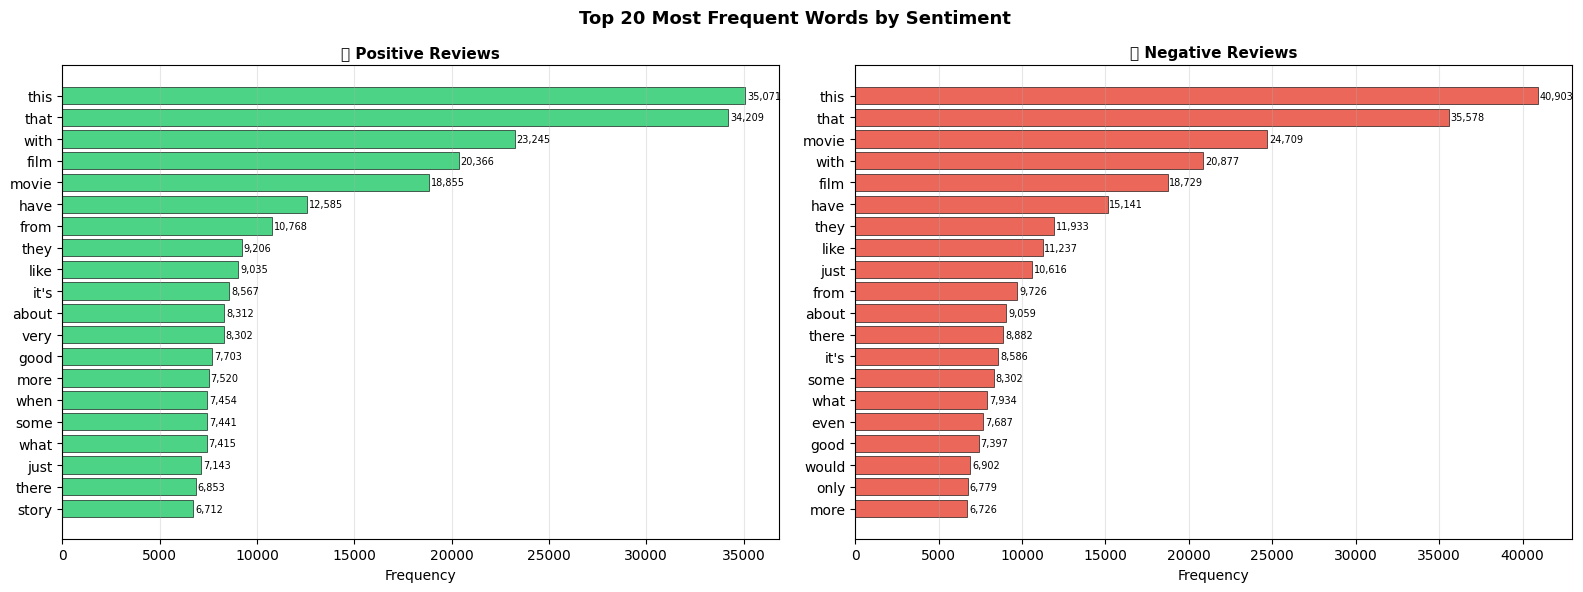

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 20 Most Frequent Words by Sentiment',
             fontsize=13, fontweight='bold')

reverse_word_index = {v: k for k, v in word_index.items()}

def get_top_words(reviews, labels, target_label, top_n=20):
    words = []
    for review, label in zip(reviews, labels):
        if label == target_label:
            for token in review:
                word = reverse_word_index.get(token - 3, None)
                if word and len(word) > 3:  # skip short words
                    words.append(word)
    return Counter(words).most_common(top_n)

pos_words = get_top_words(X_train_raw, y_train_raw, 1)
neg_words = get_top_words(X_train_raw, y_train_raw, 0)

for ax, words, color, title in zip(
    axes,
    [pos_words, neg_words],
    ['#2ecc71', '#e74c3c'],
    ['⭐ Positive Reviews', '👎 Negative Reviews']
):
    w, c = zip(*words)
    bars = ax.barh(list(w)[::-1], list(c)[::-1],
                   color=color, edgecolor='black', lw=0.5, alpha=0.85)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.grid(axis='x', alpha=0.3)
    for bar, cnt in zip(bars, list(c)[::-1]):
        ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                f'{cnt:,}', va='center', fontsize=7)

plt.tight_layout()
plt.savefig('04_top_words.png', dpi=120, bbox_inches='tight')
plt.show()

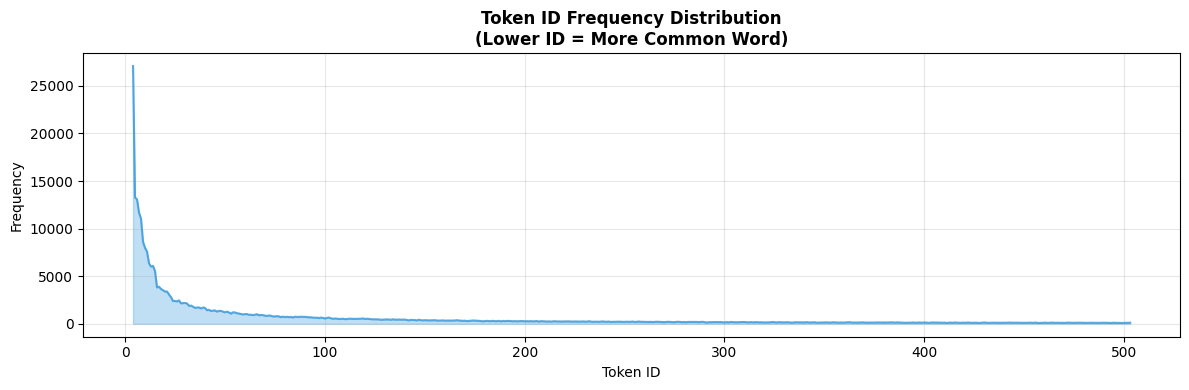

In [14]:
fig, ax = plt.subplots(figsize=(12, 4))

all_tokens = [token for review in X_train_raw[:2000]
              for token in review if token > 3]
token_freq = Counter(all_tokens)
x_vals     = sorted(token_freq.keys())[:500]
y_vals     = [token_freq[x] for x in x_vals]

ax.plot(x_vals, y_vals, color='#3498db', lw=1.5, alpha=0.8)
ax.fill_between(x_vals, y_vals, alpha=0.3, color='#3498db')
ax.set_title('Token ID Frequency Distribution\n(Lower ID = More Common Word)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Token ID')
ax.set_ylabel('Frequency')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('05_token_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

In [15]:
EMBED_DIM = 64   # Embedding dimension

def build_rnn_model():
    inputs = keras.Input(shape=(MAXLEN,), name='input')

    # Embedding Layer
    x = layers.Embedding(
        input_dim    = NUM_WORDS,
        output_dim   = EMBED_DIM,
        input_length = MAXLEN,
        name         = 'embedding'
    )(inputs)

    x = layers.SpatialDropout1D(0.2, name='spatial_dropout')(x)

    # Bidirectional LSTM Layer 1
    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True, dropout=0.2,
                    recurrent_dropout=0.1),
        name='bilstm_1'
    )(x)

    # Bidirectional GRU Layer
    x = layers.Bidirectional(
        layers.GRU(32, return_sequences=True, dropout=0.2,
                   recurrent_dropout=0.1),
        name='bigru'
    )(x)

    # Attention-style Global Pooling
    avg_pool = layers.GlobalAveragePooling1D(name='avg_pool')(x)
    max_pool = layers.GlobalMaxPooling1D(name='max_pool')(x)
    x = layers.Concatenate(name='concat')([avg_pool, max_pool])

    # Dense Classifier
    x = layers.Dense(64, activation='relu', name='dense1')(x)
    x = layers.BatchNormalization(name='bn')(x)
    x = layers.Dropout(0.4, name='dropout')(x)

    outputs = layers.Dense(1, activation='sigmoid',
                           name='output')(x)

    model = keras.Model(inputs, outputs, name='IMDB_RNN')
    return model

model = build_rnn_model()

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy',
                 keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
)

model.summary()
print(f"\n✅ RNN Model Built!")
print(f"   Total Parameters : {model.count_params():,}")

Model: "IMDB_RNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 200)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 64)   │    640,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout     │ (None, 200, 64)   │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 200, 128)  │     66,048 │ spatial_dropout[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bigru               │ (None, 200, 64)   │     31,104 │ bilstm_1[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ avg_pool            │ (None, 64)        │          0 │ bigru[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pool            │ (None, 64)        │          0 │ bigru[0][0]       │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 128)       │          0 │ avg_pool[0][0],   │
│ (Concatenate)       │                   │            │ max_pool[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 64)        │      8,256 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn                  │ (None, 64)        │        256 │ dense1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ bn[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 745,729 (2.84 MB)

 Trainable params: 745,601 (2.84 MB)

 Non-trainable params: 128 (512.00 B)


✅ RNN Model Built!
   Total Parameters : 745,729


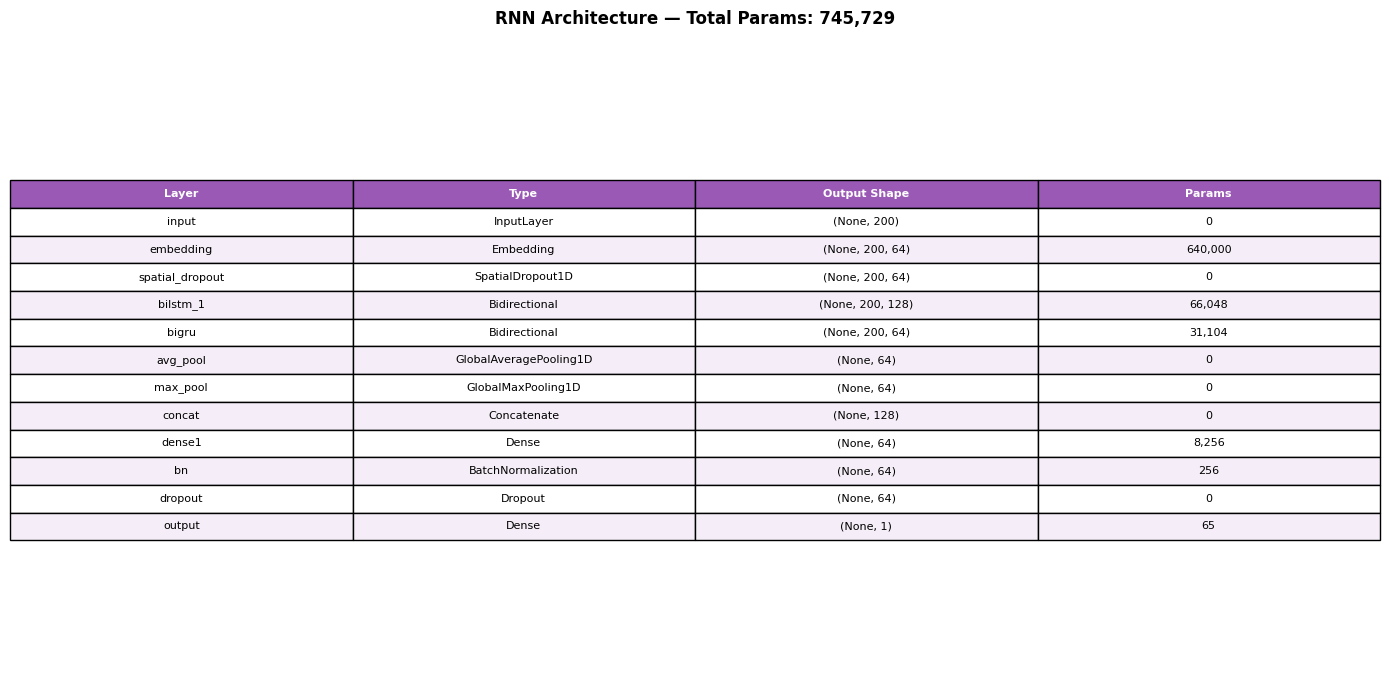

In [31]:
layer_data = []
for layer in model.layers:
    # Use layer.output.shape to get the output shape for all layers
    shape_info = str(layer.output.shape)

    layer_data.append({
        'Layer'      : layer.name,
        'Type'       : type(layer).__name__,
        'Output Shape': shape_info,
        'Params'     : f"{layer.count_params():,}"
    })

df_arch = pd.DataFrame(layer_data);

fig, ax = plt.subplots(figsize=(14, len(df_arch) * 0.5 + 1))
ax.axis('off')
table = ax.table(cellText=df_arch.values,
                 colLabels=df_arch.columns,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.4)

for j in range(len(df_arch.columns)):
    table[(0,j)].set_facecolor('#9b59b6')
    table[(0,j)].set_text_props(color='white', fontweight='bold')

for i in range(1, len(df_arch)+1):
    color = '#f5eef8' if i % 2 == 0 else 'white'
    for j in range(len(df_arch.columns)):
        table[(i,j)].set_facecolor(color)

total_p = model.count_params()
plt.title(f'RNN Architecture — Total Params: {total_p:,}',
          fontsize=12, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('06_model_architecture.png', dpi=120, bbox_inches='tight')
plt.show()

In [17]:
callbacks = [
    EarlyStopping(
        monitor             = 'val_accuracy',
        patience            = 5,
        restore_best_weights= True,
        verbose             = 1
    ),
    ModelCheckpoint(
        filepath       = 'best_rnn_model.keras',
        monitor        = 'val_accuracy',
        save_best_only = True,
        verbose        = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,
        min_lr   = 1e-6,
        verbose  = 1
    )
]

print("  Epochs     : 15 (EarlyStopping enabled)")
print("  Batch Size : 128")
print("  Optimizer  : Adam (lr=0.001)")
print("  Loss       : Binary Crossentropy\n")

history = model.fit(
    X_train_f, y_train_f,
    validation_data = (X_val, y_val),
    epochs          = 15,
    batch_size      = 128,
    callbacks       = callbacks,
    verbose         = 1
)

print("\n✅ Training Complete!")
best_val_acc = max(history.history['val_accuracy'])
best_ep      = history.history['val_accuracy'].index(best_val_acc) + 1
print(f"   Best Val Accuracy : {best_val_acc*100:.2f}%  (Epoch {best_ep})")

  Epochs     : 15 (EarlyStopping enabled)
  Batch Size : 128
  Optimizer  : Adam (lr=0.001)
  Loss       : Binary Crossentropy

Epoch 1/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6442 - auc: 0.7055 - loss: 0.5929 - precision: 0.6413 - recall: 0.6538
Epoch 1: val_accuracy improved from None to 0.87093, saving model to best_rnn_model.keras

Epoch 1: finished saving model to best_rnn_model.keras
167/167 ━━━━━━━━━━━━━━━━━━━━ 448s 3s/step - accuracy: 0.7528 - auc: 0.8474 - loss: 0.4788 - precision: 0.7479 - recall: 0.7626 - val_accuracy: 0.8709 - val_auc: 0.9346 - val_loss: 0.5788 - val_precision: 0.8717 - val_recall: 0.8699 - learning_rate: 0.0010
Epoch 2/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8857 - auc: 0.9513 - loss: 0.2849 - precision: 0.8895 - recall: 0.8836
Epoch 2: val_accuracy improved from 0.87093 to 0.87147, saving model to best_rnn_model.keras

Epoch 2: finished saving model to best_rnn_model.keras
167/167 ━━━━━━━━━━━━━━━━━━━━ 393s 2s/step - accur

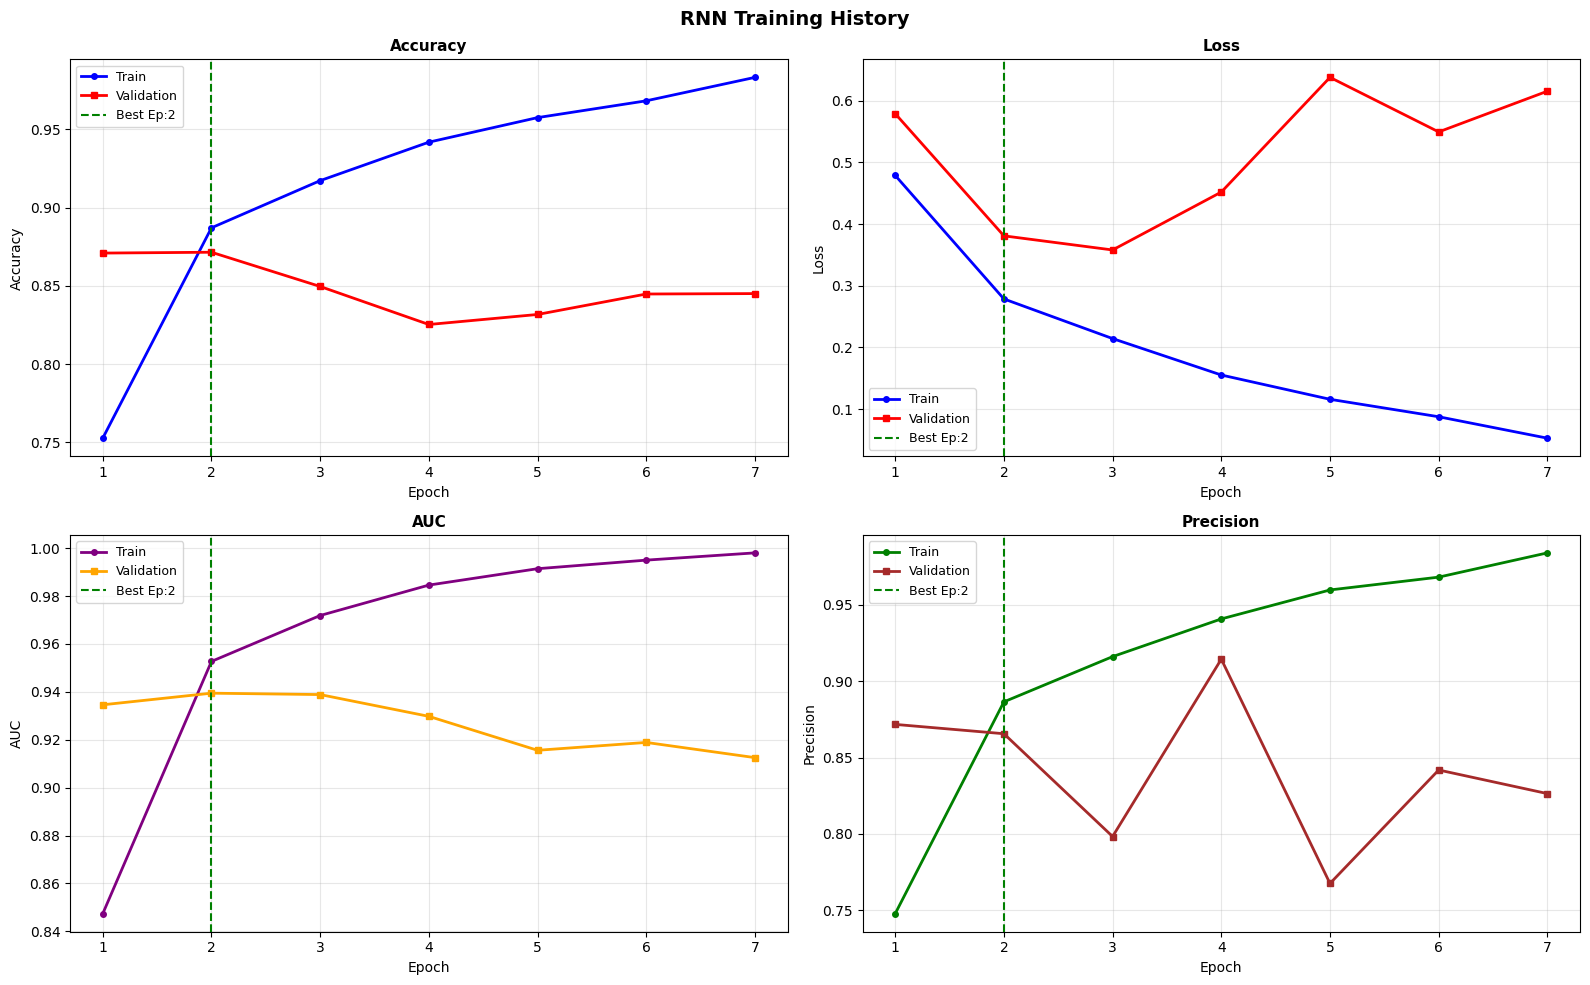

In [18]:
ep   = range(1, len(history.history['accuracy']) + 1)
keys = list(history.history.keys())

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('RNN Training History', fontsize=14, fontweight='bold')

plot_cfg = [
    ('accuracy',  'val_accuracy',  'Accuracy',  'blue',   'red'),
    ('loss',      'val_loss',      'Loss',      'blue',   'red'),
    ('auc',       'val_auc',       'AUC',       'purple', 'orange'),
    ('precision', 'val_precision', 'Precision', 'green',  'brown'),
]

for ax, (train_k, val_k, title, tc, vc) in zip(axes.flatten(), plot_cfg):
    if train_k in history.history:
        ax.plot(ep, history.history[train_k],
                f'-o', color=tc, lw=2, ms=4, label=f'Train')
    if val_k in history.history:
        ax.plot(ep, history.history[val_k],
                f'-s', color=vc, lw=2, ms=4, label=f'Validation')
    ax.axvline(best_ep, color='green', ls='--',
               lw=1.5, label=f'Best Ep:{best_ep}')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('07_training_history.png', dpi=120, bbox_inches='tight')
plt.show()

In [19]:
best_model = load_model('best_rnn_model.keras')

# Evaluate
results = {}
for name, X, y in [('Train', X_train_f, y_train_f),
                   ('Val',   X_val,     y_val),
                   ('Test',  X_test_pad, y_test)]:
    loss, acc, auc_s, prec, rec = best_model.evaluate(X, y, verbose=0)
    results[name] = {
        'Loss': loss, 'Accuracy': acc,
        'AUC': auc_s, 'Precision': prec, 'Recall': rec,
        'F1': 2 * prec * rec / (prec + rec + 1e-8)
    }

# Print Table
print(f"\n{'Metric':<12}", end='')
for name in results: print(f"{name:>10}", end='')
print()
print("=" * 42)
for metric in ['Loss', 'Accuracy', 'AUC', 'Precision', 'Recall', 'F1']:
    print(f"{metric:<12}", end='')
    for name in results:
        print(f"{results[name][metric]:>10.4f}", end='')
    print()

# Predictions
y_pred_prob = best_model.predict(X_test_pad, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)
y_true      = y_test.astype(int)

print("\n📊 CLASSIFICATION REPORT\n")
print(classification_report(y_true, y_pred,
      target_names=['Negative 👎', 'Positive ⭐']))


Metric           Train       Val      Test
Loss            0.3170    0.3809    0.3978
Accuracy        0.9398    0.8715    0.8547
AUC             0.9832    0.9394    0.9318
Precision       0.9369    0.8656    0.8534
Recall          0.9431    0.8795    0.8565
F1              0.9400    0.8725    0.8549

📊 CLASSIFICATION REPORT

              precision    recall  f1-score   support

  Negative 👎       0.86      0.85      0.85     12500
  Positive ⭐       0.85      0.86      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



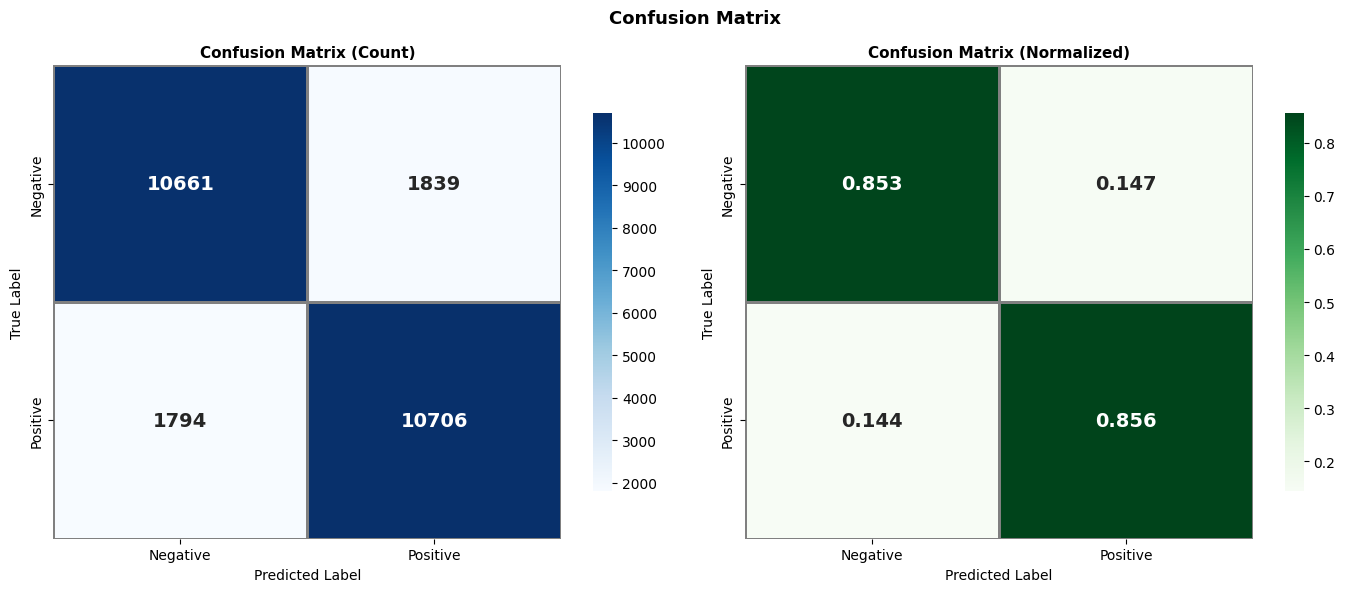

   True Negative  (TN) : 10,661
   False Positive (FP) : 1,839
   False Negative (FN) : 1,794
   True Positive  (TP) : 10,706


In [20]:
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
labels  = ['Negative', 'Positive']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrix', fontsize=13, fontweight='bold')

for ax, data, fmt, cmap, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.3f'],
    ['Blues', 'Greens'],
    ['Count', 'Normalized']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=labels, yticklabels=labels,
                ax=ax, linewidths=1, linecolor='gray',
                annot_kws={'size': 14, 'weight': 'bold'},
                cbar_kws={'shrink': 0.8})
    ax.set_title(f'Confusion Matrix ({title})',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label',      fontsize=10)

plt.tight_layout()
plt.savefig('08_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"   True Negative  (TN) : {tn:,}")
print(f"   False Positive (FP) : {fp:,}")
print(f"   False Negative (FN) : {fn:,}")
print(f"   True Positive  (TP) : {tp:,}")

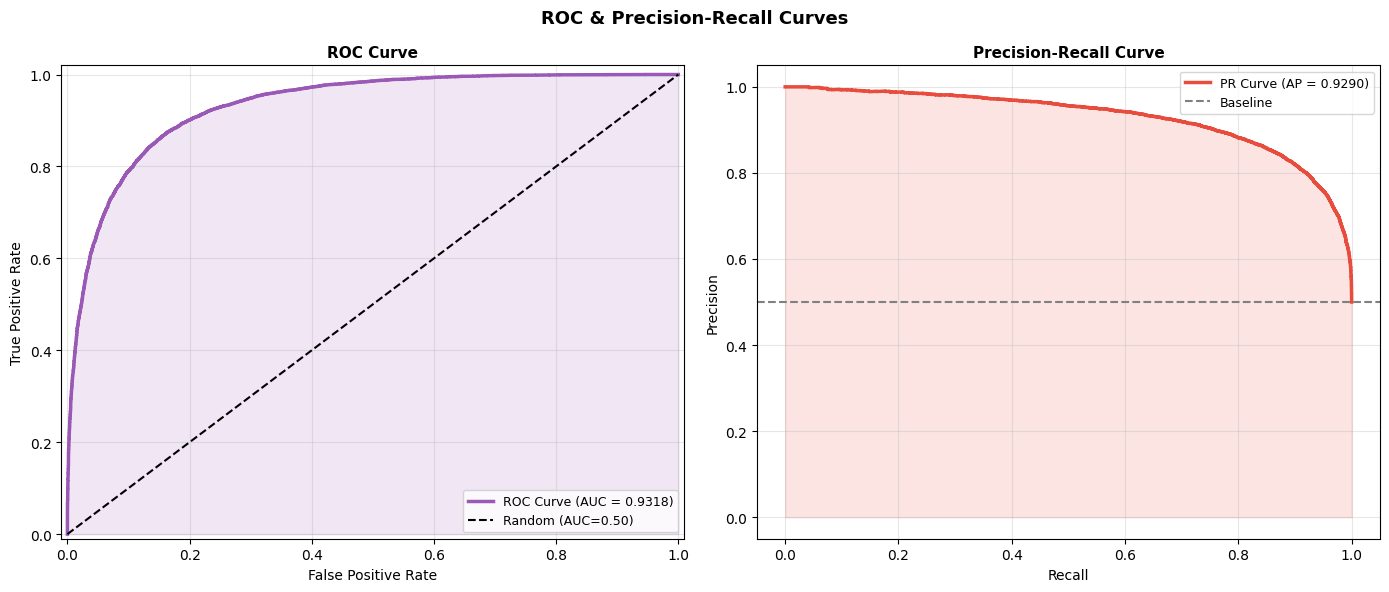

   ROC-AUC Score        : 0.9318
   Average Precision    : 0.9290


In [21]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ROC & Precision-Recall Curves',
             fontsize=13, fontweight='bold')

# ── ROC Curve ──
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc_val = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='#9b59b6', lw=2.5,
             label=f'ROC Curve (AUC = {roc_auc_val:.4f})')
axes[0].plot([0,1], [0,1], 'k--', lw=1.5, label='Random (AUC=0.50)')
axes[0].fill_between(fpr, tpr, alpha=0.15, color='#9b59b6')
axes[0].set_title('ROC Curve', fontsize=11, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
axes[0].set_xlim([-0.01, 1.01])
axes[0].set_ylim([-0.01, 1.02])

# ── Precision-Recall Curve ──
prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_pred_prob)
ap_score = average_precision_score(y_true, y_pred_prob)

axes[1].plot(rec_curve, prec_curve, color='#e74c3c', lw=2.5,
             label=f'PR Curve (AP = {ap_score:.4f})')
axes[1].fill_between(rec_curve, prec_curve, alpha=0.15, color='#e74c3c')
axes[1].axhline(y=0.5, color='gray', ls='--', lw=1.5, label='Baseline')
axes[1].set_title('Precision-Recall Curve', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('09_roc_pr_curves.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"   ROC-AUC Score        : {roc_auc_val:.4f}")
print(f"   Average Precision    : {ap_score:.4f}")

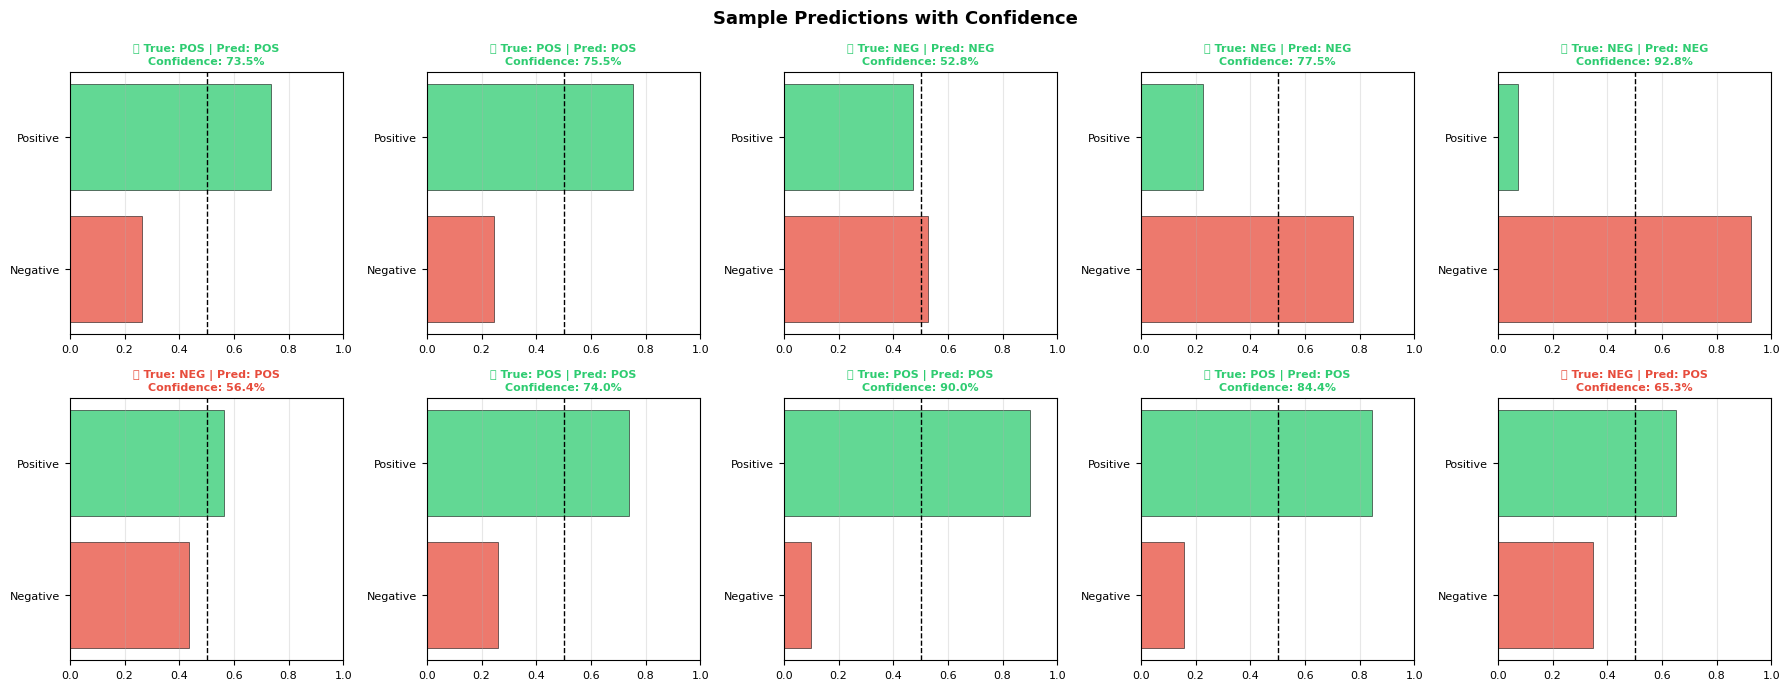


Detailed Predictions:

✅ Review 1: True=POS | Pred=⭐ POS | Conf=73.5%
   '<START> i must tell you the truth the only reason i wanted to see this movie was...'

✅ Review 2: True=POS | Pred=⭐ POS | Conf=75.5%
   '<START> the only reason the duke is tops one of several race movies made during ...'

✅ Review 3: True=NEG | Pred=👎 NEG | Conf=52.8%
   '<START> i really liked the idea of traveling between <UNK> and i even liked the ...'

✅ Review 4: True=NEG | Pred=👎 NEG | Conf=77.5%
   '<START> i've been surprised by the enthusiastic response to this film it seemed ...'

✅ Review 5: True=NEG | Pred=👎 NEG | Conf=92.8%
   '<START> i never fell asleep during a movie never this movie did the impossible b...'

❌ Review 6: True=NEG | Pred=⭐ POS | Conf=56.4%
   '<START> why did they change the cute <UNK> television show we all know and love ...'

✅ Review 7: True=POS | Pred=⭐ POS | Conf=74.0%
   '<START> i have read reviews of this film that found it and i am at a loss to und...'

✅ Review 8: True=

In [22]:
# Predict on 10 test samples
sample_idx   = np.random.choice(len(X_test_pad), 10, replace=False)
sample_X     = X_test_pad[sample_idx]
sample_y     = y_true[sample_idx]
sample_probs = best_model.predict(sample_X, verbose=0).flatten()
sample_pred  = (sample_probs >= 0.5).astype(int)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Sample Predictions with Confidence',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, (true, pred, prob) in enumerate(
    zip(sample_y, sample_pred, sample_probs)
):
    correct = (true == pred)
    color   = '#2ecc71' if correct else '#e74c3c'
    emoji   = '✅' if correct else '❌'

    # Sentiment bar
    axes[i].barh(['Negative', 'Positive'],
                 [1-prob, prob],
                 color=['#e74c3c', '#2ecc71'], alpha=0.75,
                 edgecolor='black', lw=0.5)
    axes[i].axvline(0.5, color='black', ls='--', lw=1)
    axes[i].set_xlim(0, 1)
    axes[i].set_title(
        f"{emoji} True: {'POS' if true==1 else 'NEG'} | "
        f"Pred: {'POS' if pred==1 else 'NEG'}\n"
        f"Confidence: {max(prob, 1-prob)*100:.1f}%",
        fontsize=8, fontweight='bold', color=color
    )
    axes[i].tick_params(labelsize=8)
    axes[i].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('10_sample_predictions.png', dpi=120, bbox_inches='tight')
plt.show()

# Print text predictions
print("\nDetailed Predictions:")
for i, (idx, true, pred, prob) in enumerate(
    zip(sample_idx, sample_y, sample_pred, sample_probs)
):
    em   = "✅" if true == pred else "❌"
    sent = '⭐ POS' if pred == 1 else '👎 NEG'
    text = decode_review(X_test_raw[idx])[:80]
    print(f"\n{em} Review {i+1}: True={'POS' if true==1 else 'NEG'} "
          f"| Pred={sent} | Conf={max(prob,1-prob)*100:.1f}%")
    print(f"   '{text}...'")

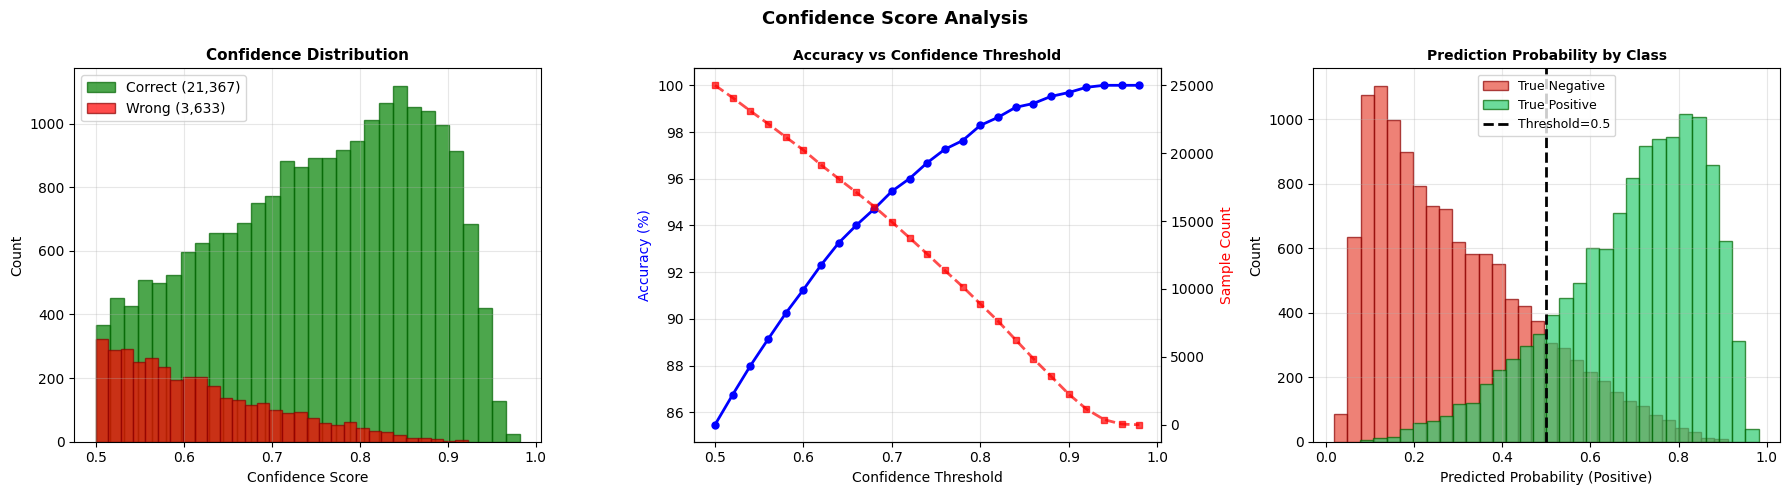

   Correct   Avg Confidence : 75.32%
   Incorrect Avg Confidence : 61.63%


In [23]:
conf_scores    = np.maximum(y_pred_prob, 1 - y_pred_prob)
correct_conf   = conf_scores[y_pred == y_true]
incorrect_conf = conf_scores[y_pred != y_true]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confidence Score Analysis',
             fontsize=13, fontweight='bold')

# Histogram
axes[0].hist(correct_conf, bins=30, alpha=0.7, color='green',
             label=f'Correct ({len(correct_conf):,})',
             edgecolor='darkgreen')
axes[0].hist(incorrect_conf, bins=30, alpha=0.7, color='red',
             label=f'Wrong ({len(incorrect_conf):,})',
             edgecolor='darkred')
axes[0].set_title('Confidence Distribution', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Threshold vs Accuracy
thresholds = np.arange(0.5, 1.0, 0.02)
acc_by_thresh, count_by_thresh = [], []
for thr in thresholds:
    mask   = conf_scores >= thr
    if mask.sum() > 0:
        acc    = (y_pred[mask] == y_true[mask]).mean()
        acc_by_thresh.append(acc)
        count_by_thresh.append(mask.sum())
    else:
        acc_by_thresh.append(np.nan)
        count_by_thresh.append(0)

ax2 = axes[1]
ax2_twin = ax2.twinx()
ax2.plot(thresholds, [a*100 for a in acc_by_thresh],
         'b-o', lw=2, ms=5, label='Accuracy %')
ax2_twin.plot(thresholds, count_by_thresh,
              'r--s', lw=2, ms=5, label='Sample Count', alpha=0.7)
ax2.set_title('Accuracy vs Confidence Threshold',
              fontsize=10, fontweight='bold')
ax2.set_xlabel('Confidence Threshold')
ax2.set_ylabel('Accuracy (%)', color='blue')
ax2_twin.set_ylabel('Sample Count', color='red')
ax2.grid(alpha=0.3)

# Probability Distribution
axes[2].hist(y_pred_prob[y_true==0], bins=30, alpha=0.7,
             color='#e74c3c', label='True Negative', edgecolor='darkred')
axes[2].hist(y_pred_prob[y_true==1], bins=30, alpha=0.7,
             color='#2ecc71', label='True Positive', edgecolor='darkgreen')
axes[2].axvline(0.5, color='black', ls='--', lw=2, label='Threshold=0.5')
axes[2].set_title('Prediction Probability by Class',
                  fontsize=10, fontweight='bold')
axes[2].set_xlabel('Predicted Probability (Positive)')
axes[2].set_ylabel('Count')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('11_confidence_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"   Correct   Avg Confidence : {correct_conf.mean()*100:.2f}%")
print(f"   Incorrect Avg Confidence : {incorrect_conf.mean()*100:.2f}%")

In [24]:
best_model.save('imdb_rnn_model.keras')
print("✅ imdb_rnn_model.keras")

best_model.save('imdb_rnn_model.h5')
print("✅ imdb_rnn_model.h5")

best_model.save_weights('imdb_rnn_weights.weights.h5')
print("✅ imdb_rnn_weights.weights.h5")

with open('imdb_rnn_architecture.json', 'w') as f:
    f.write(best_model.to_json())
print("✅ imdb_rnn_architecture.json")

info = {
    "model"          : "IMDB_RNN",
    "dataset"        : "IMDB Movie Reviews",
    "date"           : datetime.now().strftime("%Y-%m-%d %H:%M"),
    "architecture"   : "BiLSTM + BiGRU + GlobalPooling",
    "vocab_size"     : NUM_WORDS,
    "max_length"     : MAXLEN,
    "embed_dim"      : EMBED_DIM,
    "test_accuracy"  : round(float(results['Test']['Accuracy']), 4),
    "test_auc"       : round(float(results['Test']['AUC']), 4),
    "test_f1"        : round(float(results['Test']['F1']), 4),
    "total_params"   : int(best_model.count_params()),
    "classes"        : {0: "Negative", 1: "Positive"}
}
with open('model_info.json', 'w') as f:
    json.dump(info, f, indent=2)

✅ imdb_rnn_model.keras
✅ imdb_rnn_model.h5
✅ imdb_rnn_weights.weights.h5
✅ imdb_rnn_architecture.json


In [25]:
all_files = [
    'imdb_rnn_model.keras',
    'imdb_rnn_model.h5',
    'imdb_rnn_weights.weights.h5',
    'imdb_rnn_architecture.json',
    'model_info.json',
    '01_class_distribution.png',
    '02_review_length.png',
    '03_padding_effect.png',
    '04_top_words.png',
    '05_token_distribution.png',
    '06_model_architecture.png',
    '07_training_history.png',
    '08_confusion_matrix.png',
    '09_roc_pr_curves.png',
    '10_sample_predictions.png',
    '11_confidence_analysis.png',
]

zip_name = 'imdb_rnn_complete.zip'
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in all_files:
        if os.path.exists(f):
            zf.write(f)
            print(f"   Added : {f}")

zip_mb = os.path.getsize(zip_name) / (1024*1024)
print(f"\n📦 ZIP: {zip_name}  ({zip_mb:.1f} MB)")

try:
    from google.colab import files
    print("\n📥 Colab Download Starting...")
    files.download(zip_name)
    files.download('imdb_rnn_model.h5')
    print("✅ Download Started!")
except ImportError:
    print("\n💡 Local Jupyter — Files saved in current folder:")
    for f in all_files:
        if os.path.exists(f):
            kb = os.path.getsize(f) / 1024
            print(f"   📄 {f:<45} ({kb:.0f} KB)")
    print(f"\n   📦 {zip_name}  ({zip_mb:.1f} MB)")

   Added : imdb_rnn_model.keras
   Added : imdb_rnn_model.h5
   Added : imdb_rnn_weights.weights.h5
   Added : imdb_rnn_architecture.json
   Added : model_info.json
   Added : 01_class_distribution.png
   Added : 02_review_length.png
   Added : 03_padding_effect.png
   Added : 04_top_words.png
   Added : 05_token_distribution.png
   Added : 07_training_history.png
   Added : 08_confusion_matrix.png
   Added : 09_roc_pr_curves.png
   Added : 10_sample_predictions.png
   Added : 11_confidence_analysis.png

📦 ZIP: imdb_rnn_complete.zip  (24.5 MB)

📥 Colab Download Starting...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download Started!


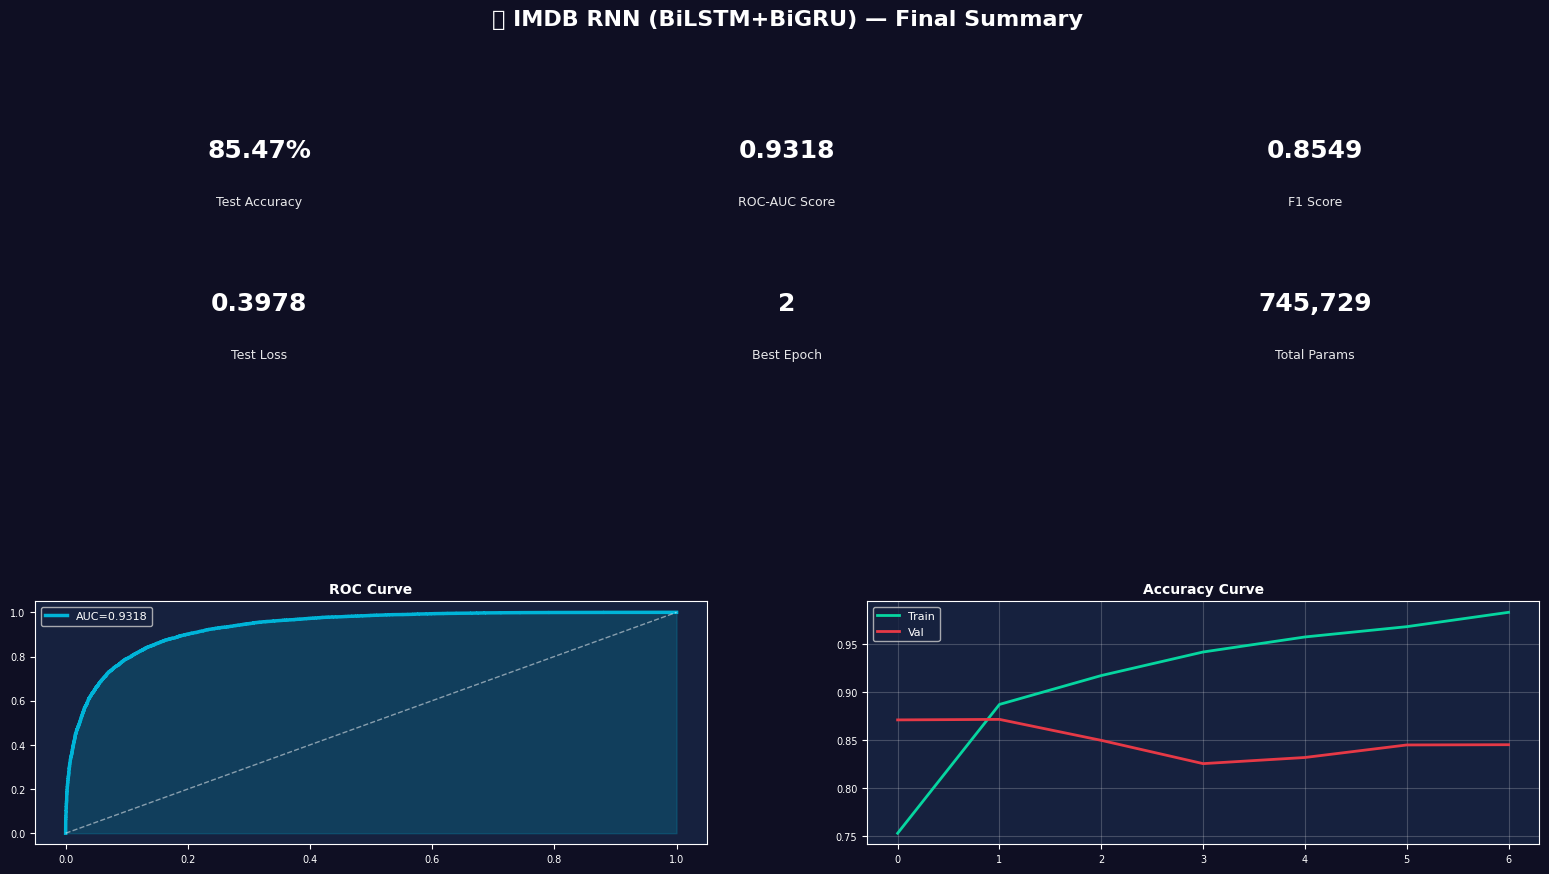

In [26]:
test_acc_v  = results['Test']['Accuracy']
test_auc_v  = results['Test']['AUC']
test_f1_v   = results['Test']['F1']
test_loss_v = results['Test']['Loss']

fig = plt.figure(figsize=(16, 9))
fig.patch.set_facecolor('#0f0f23')

fig.text(0.5, 0.96,
         '🏆 IMDB RNN (BiLSTM+BiGRU) — Final Summary',
         ha='center', fontsize=16, fontweight='bold', color='white')

# ── Metric Cards ──
metrics = [
    ('Test Accuracy',  f'{test_acc_v*100:.2f}%',        '#00b4d8'),
    ('ROC-AUC Score',  f'{test_auc_v:.4f}',             '#06d6a0'),
    ('F1 Score',       f'{test_f1_v:.4f}',              '#ffd166'),
    ('Test Loss',      f'{test_loss_v:.4f}',            '#e63946'),
    ('Best Epoch',     f'{best_ep}',                    '#a8dadc'),
    ('Total Params',   f'{best_model.count_params():,}','#f4a261'),
]

for i, (label, value, color) in enumerate(metrics):
    ax = fig.add_axes([0.03+(i%3)*0.33, 0.74-(i//3)*0.17, 0.28, 0.13])
    ax.set_facecolor(color)
    ax.text(0.5, 0.62, value, ha='center', va='center',
            fontsize=18, fontweight='bold', color='white',
            transform=ax.transAxes)
    ax.text(0.5, 0.18, label, ha='center', va='center',
            fontsize=9, color='white', alpha=0.9,
            transform=ax.transAxes)
    ax.axis('off')

# ── ROC Curve ──
ax_roc = fig.add_axes([0.03, 0.05, 0.42, 0.27])
ax_roc.set_facecolor('#16213e')
ax_roc.plot(fpr, tpr, color='#00b4d8', lw=2.5,
            label=f'AUC={roc_auc_val:.4f}')
ax_roc.plot([0,1],[0,1],'w--', lw=1, alpha=0.5)
ax_roc.fill_between(fpr, tpr, alpha=0.2, color='#00b4d8')
ax_roc.set_title('ROC Curve', color='white', fontsize=10, fontweight='bold')
ax_roc.tick_params(colors='white', labelsize=7)
ax_roc.legend(fontsize=8, facecolor='#16213e', labelcolor='white')
for sp in ax_roc.spines.values(): sp.set_color('white')

# ── Accuracy Curve ──
ax_acc = fig.add_axes([0.55, 0.05, 0.42, 0.27])
ax_acc.set_facecolor('#16213e')
ax_acc.plot(history.history['accuracy'],
            color='#06d6a0', lw=2, label='Train')
ax_acc.plot(history.history['val_accuracy'],
            color='#e63946', lw=2, label='Val')
ax_acc.set_title('Accuracy Curve', color='white',
                 fontsize=10, fontweight='bold')
ax_acc.tick_params(colors='white', labelsize=7)
ax_acc.legend(fontsize=8, facecolor='#16213e', labelcolor='white')
ax_acc.grid(alpha=0.2, color='white')
for sp in ax_acc.spines.values(): sp.set_color('white')

plt.savefig('12_final_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f23')
plt.show()

In [27]:
# ── Final Print ──
print("\n" + "="*55)
print("  ✅ ALL DONE!")
print("="*55)
print(f"  Dataset      : IMDB Movie Reviews (50,000 reviews)")
print(f"  Task         : Binary Sentiment Classification")
print(f"  Architecture : BiLSTM + BiGRU + GlobalPooling")
print(f"  Test Accuracy: {test_acc_v*100:.2f}%")
print(f"  ROC-AUC      : {test_auc_v:.4f}")
print(f"  F1 Score     : {test_f1_v:.4f}")
print(f"  Model Saved  : .keras | .h5 | weights | json")
print(f"  Charts Saved : 12 visualization files")
print("="*55)


  ✅ ALL DONE!
  Dataset      : IMDB Movie Reviews (50,000 reviews)
  Task         : Binary Sentiment Classification
  Architecture : BiLSTM + BiGRU + GlobalPooling
  Test Accuracy: 85.47%
  ROC-AUC      : 0.9318
  F1 Score     : 0.8549
  Model Saved  : .keras | .h5 | weights | json
  Charts Saved : 12 visualization files
